In [ ]:
import numpy as np
import pandas as pd
import os
from dotenv import load_dotenv
load_dotenv(override=True)

In [ ]:
movies_data = pd.read_csv(os.getenv("IMDB_TOP_1000_FILE_PATH"))
movies_data.head()

`groupby()` is applied to columns containing repeating values (typically categorical columns) to group similar records and perform aggregate operations such as `sum()` `mean()` `count()` `min()` and `max()` on each group.

In [ ]:
genres = movies_data.groupby('Genre')
# Aggregate function
genres.sum()

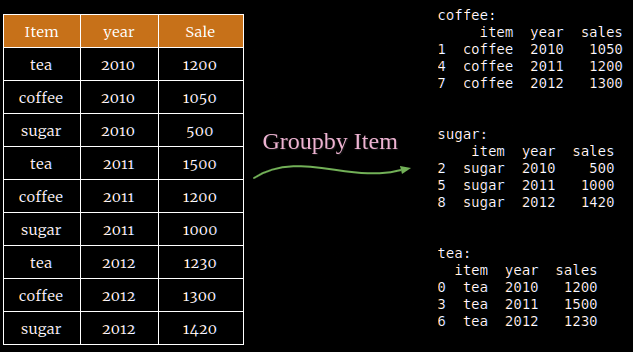
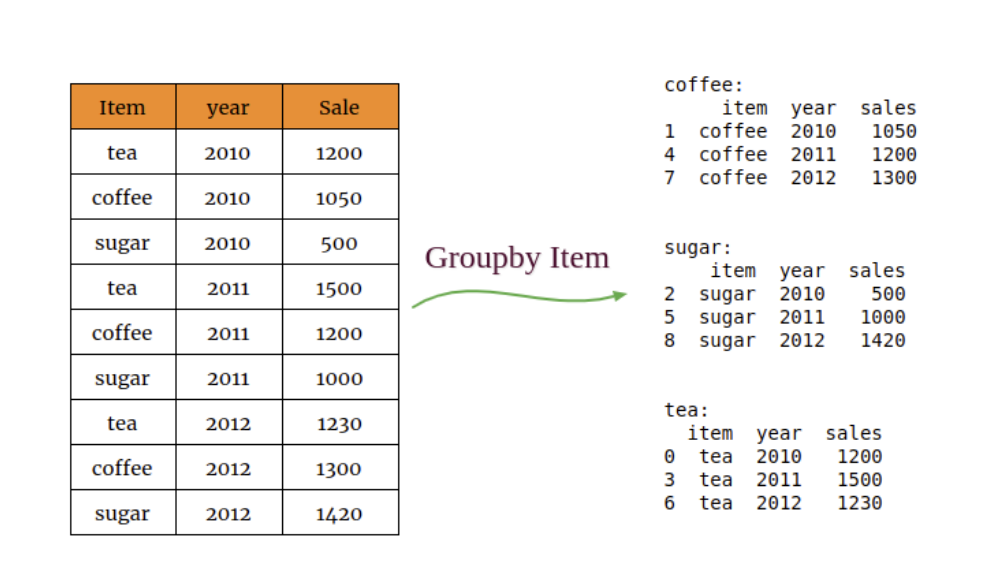

In [ ]:
# Top 3 Genre
movies_data.groupby("Genre").sum()["Gross"].sort_values(ascending=False).head(3)

In [ ]:
# optimal
movies_data.groupby("Genre")["Gross"].sum().sort_values(ascending=False).head(3)

In [ ]:
movies_data.groupby("Genre")["IMDB_Rating"].mean().sort_values(ascending=False).head(3)

In [ ]:
# popular director based on votes
movies_data.groupby("Director")["No_of_Votes"].sum().sort_values(ascending=False).head(1)

In [ ]:
# hihest rated movie in each Genre
movies_data.groupby("Genre")[["Series_Title","IMDB_Rating"]].min()
movies_data.groupby("Genre")[["Series_Title","IMDB_Rating"]].max()

In [ ]:
movies_data["Star1"].value_counts()
movies_data.groupby("Star1")["Series_Title"].count().sort_values(ascending=False)

In [ ]:
# uniques Genre
len(movies_data.groupby("Genre"))
movies_data["Genre"].nunique()

In [ ]:
movies_data.groupby("Genre").size()
# groups the dataset by the Genre column and returns the number of rows (records) in each genre

In [ ]:
# first movie in every genre 
genres.first()
# last movie in every genre 
genres.last()
# nth movie in every genre 
genres.nth(7) #*6th movie in each genre 

In [ ]:
# get movies of specific genre
genres.get_group("Mystery")

In [ ]:
genres.groups
genres.describe()

In [ ]:
# genres.sample()
genres.sample(2,replace=True) 

`replace=True` allows the same row to be selected more than once during sampling. It is useful when a group has fewer than ***n*** rows

In [ ]:
# Aggregate Methods on different column
genres.agg({
    'Runtime':'mean',
    'IMDB_Rating':'mean',
    'Gross':'sum',
})

In [ ]:
genres["Gross"].agg(['min','max','mean','sum'])

In [ ]:
# Aggregate Methods on different column
genres.agg({
    'Runtime':['mean','max','min'],
    'IMDB_Rating':['mean','max','min'],
    'Gross':['mean','max','min']
})

In [ ]:
# movies start with A
def start_with_A(group):
    return group["Series_Title"].str.startswith('A').sum()

genres.apply(start_with_A)

In [ ]:
# rank
def rank_movie(group):
    group["Genre Rank"] = group["IMDB_Rating"].rank(ascending=True)
    return group

genres.apply(rank_movie)

In [ ]:
# normalized Rank
def normalized_rank(group):
    group["Normalized Genre Rank"] = (group["IMDB_Rating"] - group["IMDB_Rating"].min())/(group["IMDB_Rating"].max() - group["IMDB_Rating"].min())
    return group

genres.apply(normalized_rank)

In [ ]:
# groupby on multiple column
actor_director = movies_data.groupby(["Director","Star1"])
actor_director.size()
actor_director.get_group(('Aditya Dhar', 'Vicky Kaushal')) 

In [ ]:
actor_director["Gross"].sum().sort_values(ascending=False)

In [ ]:
actor_genre = movies_data.groupby(["Star1","Genre"])
actor_genre["Metascore"].mean().reset_index().sort_values("Metascore",ascending=False)

In [ ]:
ipl_data = pd.read_csv(os.getenv("IPL_DELIVERIES_FILE_PATH"))
ipl_data.shape
ipl_data.sample()

In [ ]:
batsman = ipl_data.groupby("batsman")
batsman["batsman_runs"].sum().sort_values(ascending=False).head(10)

In [ ]:
ipl_data[ipl_data["batsman_runs"] == 6].groupby("batsman")["batsman_runs"].count().sort_values(ascending=False).head(1).index[0]

In [ ]:
death_overs = ipl_data[ipl_data["over"]>15]
death_overs = death_overs[(death_overs["batsman_runs"] == 4) | (death_overs["batsman_runs"] == 6)]
death_overs.groupby("batsman").count().sort_values("total_runs",ascending=False)

In [ ]:
# Virat Kohli's Record
vk_data = ipl_data[ipl_data["batsman"] == "V Kohli"]
vk_data.groupby("bowling_team")["batsman_runs"].sum().reset_index()


In [ ]:
def highest_score(batsman_name):
    return ipl_data[ipl_data["batsman"] == batsman_name].groupby("match_id")["batsman_runs"].sum().sort_values(ascending=False).head(1).values[0]

print(highest_score("MS Dhoni"))
print(highest_score("V Kohli"))